# Data Handling with Dataset and DataLoader

### Overview
In this video, we cover the complete workflow of handling data in PyTorch using `Dataset` and `DataLoader`.  

### Agenda
- **Importing Libraries** → set up PyTorch and required modules.
- **Understanding MNIST Data** → understanding how MNIST data looks like.
- **Creating Custom Dataset Class** → load `.pkl` MNIST data, convert to tensors, add flatten/transform options.  
- **Applying Optional Transforms** → normalize pixel values for stable training.  
- **Loading Dataset** → instantiate dataset with `.pkl` path, flatten, and transform settings.  
- **Creating DataLoader** → enable batching (e.g., batch size 32) and shuffling.  
- **Device Selection** → choose GPU if available, else CPU.  
- **Iterating Over a Batch** → fetch one batch, move to device, print shapes.  

### Key Takeaway
By the end, you’ll know how to build a custom dataset pipeline with preprocessing, batching, and GPU acceleration for efficient model training.

## Custom PyTorch Dataset for MNIST (.pkl)

- Load MNIST data from `.pkl` and convert to Tensor (pixel arrays + labels → tensors).  
- Define `CustomMNISTDataset` (inherits `torch.utils.data.Dataset`).  
  - Optional: flatten (28×28 → 784), apply transforms (e.g., normalization).  
- Use `torchvision.transforms` to scale pixels (0–255 → 0–1) - for stable training.  
- Wrap with `DataLoader` for batching + shuffling (e.g., batch size 32).  
- Move batches to GPU for faster training.  
- Demonstrate iterating over one batch (images + labels).  
- Supports preprocessing, batching, and GPU acceleration directly on MNIST.  

### Importing Necessary Libraries
- `torch`: PyTorch library for tensors and computations.  
- `Dataset` and `DataLoader`: for creating custom datasets and iterating in batches.  
- `pickle`: to load MNIST `.pkl` file containing pixel arrays.  
- `torchvision.transforms`: optional preprocessing like normalization.

In [1]:
import torch
from torch.utils.data import Dataset, DataLoader
import pickle
from torchvision import transforms

# Understanding MNIST Data

### What we’ll do
- **Load MNIST from `.pkl` file**.  
- **Check data structure** → pixel arrays and labels.  
- **Inspect shapes** → confirm each image is `28×28`.  
- **Visualize samples** → see how the digits look.  

### Why it matters
Before batching and training:
- We need to know how the data is stored inside `.pkl`.  
- Confirm the format: pixel intensity values `[0–255]`, labels `[0–9]`.  
- Visualization builds intuition for what the model will learn.  

Images shape: (50000, 28, 28)
Labels shape: (50000,)
Pixel range: 0.0 to 0.99609375
Unique labels: {0, 1, 2, 3, 4, 5, 6, 7, 8, 9}


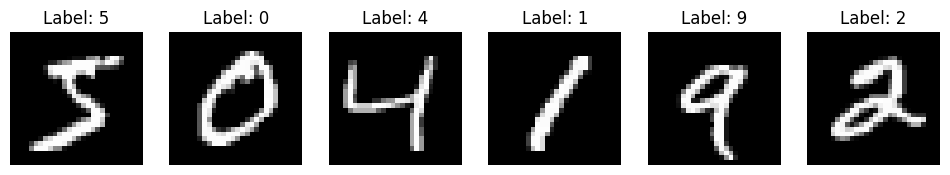

In [17]:
import pickle
import matplotlib.pyplot as plt

# Load MNIST from a .pkl file
with open("data/mnist.pkl", "rb") as f:   # <-- change path if needed
    mnist_data = pickle.load(f, encoding="latin1")[0]  # load training set

# Assuming the .pkl has 'images' and 'labels' keys
images, labels = mnist_data[0], mnist_data[1]

print("Images shape:", images.shape)   # Expect [N, 28, 28]
print("Labels shape:", labels.shape)   # Expect [N]
print("Pixel range:", images.min(), "to", images.max())
print("Unique labels:", set(labels.tolist()))  # peek first few

# Visualize first 6 images
fig, axes = plt.subplots(1, 6, figsize=(12, 2))
for i in range(6):
    axes[i].imshow(images[i], cmap="gray")
    axes[i].set_title(f"Label: {labels[i]}")
    axes[i].axis("off")
plt.show()

### Custom Dataset

- `CustomMNISTDataset` inherits from `torch.utils.data.Dataset`.  
- **Constructor (`__init__`)**:  
  - Loads `.pkl` MNIST data.  
  - Converts images + labels into PyTorch tensors.  
- **Options**:  
  - `flatten`: reshape 28×28 → 784 for fully connected networks.  
- **Transform**:  
  - Applied in `__getitem__` for preprocessing (e.g., normalization).  
- **Methods**:  
  - `__len__`: returns total samples.  
  - `__getitem__`: returns one image + label (with optional transform).  

In [3]:
class CustomMNISTDataset(Dataset):

    # defining constructor
    def __init__(self, path, flatten=True, features_to_consider=None, transform=None):
        
        images, labels = pickle.load(open(path, "rb"), encoding="latin1")[0]  # load training set
        
        x = torch.tensor(images, dtype=torch.float32)  # convert images to float32 tensor
        y = torch.tensor(labels, dtype=torch.long)     # convert labels to int64 tensor

        if flatten:                                    # flatten 28x28 → 784
            x = x.view(x.shape[0], -1)

        # set the class/dataset attributes
        self.x, self.y, self.transform = x, y, transform  # store tensors and optional transform

    # defining what is the length
    def __len__(self): 
        return len(self.y)                             # return total number of samples

    # defining how to get idx item
    def __getitem__(self, idx):
        img = self.x[idx]                              # get one image
        if self.transform: 
            img = self.transform(img)                  # apply transform if provided
        return img, self.y[idx]                        # return image and label

### Optional Transforms

- Defined using `transforms.Compose` → combine multiple preprocessing steps.  
- Example: `transforms.Lambda(lambda x: x / 255.0)`  
  - Scales pixel values 0–255 → 0–1.  
- **Why?**  
  - Normalization stabilizes training.  
  - Ensures efficient learning in neural networks.  

In [4]:
transform = transforms.Compose([
    transforms.Lambda(lambda x: x / 255.0),  # normalize pixel values to 0-1
])

### Loading Dataset

- Create dataset instance → pass `.pkl` file path.  
- Specify options:  
  - `flatten` → reshape 28×28 to 784 if needed.  
  - `transform` → apply preprocessing (e.g., normalization).  
- Loads training images + labels from `.pkl` with applied settings.  

In [5]:
dataset = CustomMNISTDataset("data/mnist.pkl", flatten=True, transform=transform)

### DataLoader for Batching and Shuffling

- Use `DataLoader` to create mini-batches (e.g., 32 samples per batch).  
- `shuffle=True` → randomizes sample order each epoch → better training.  
- Enables efficient iteration over batches during model training.  

In [6]:
loader = DataLoader(dataset, batch_size=32, shuffle=True)

### GPU Device Selection

- Check if GPU is available (`torch.cuda.is_available()`).  
- Select device:  
  - If GPU → use `"cuda"`.  
  - Else → fallback to `"cpu"`.  
- Move tensors/models to GPU for faster computation.  
- Especially useful for large datasets + deep neural networks.  

In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


### Iterating Over a Batch

- Fetch one batch from `DataLoader`:  
  - `batch_x` → images  
  - `batch_y` → labels  
- Move batch to selected device (GPU/CPU).  
- Print shapes:  
  - `batch_x.shape` → `[batch_size, 784]` if flattened  
  - `batch_y.shape` → `[batch_size]` for labels  
- Use `break` → only process first batch as an example.  

In [8]:
for batch_x, batch_y in loader:
    batch_x = batch_x.to(device)
    batch_y = batch_y.to(device)
    print("Batch X shape:", batch_x.shape)
    print("Batch Y shape:", batch_y.shape)
    break

Batch X shape: torch.Size([32, 784])
Batch Y shape: torch.Size([32])
